# Transfer Learning ImageNet to CIFAR 10

Η τεχνική του Transfer Learning είναι θεμελιωδης στην μηχανική μάθηση. Είναι ένας από τους βασικούς λόγους που τα λεγόμενα **foundation models** έχουνε δεί τόση επιτυχία.

Θα χρισομοποιήσουμε την ιδέα του Transfer Learning στο επόμενο Notebook για να προσεγγίσουμε ένα σημαντικό και δύσκολο πρόβλημα: την διάγνωση κακοήθη καρκίνου του μαστού, από υπέρηχο (ultrasound).

Η βασική ιδέα του transfer learning είναι ως εξής: εκπαιδεύουμε ένα μεγάλο (βαθύ, με πολλές παραμέτρους) νευρωνικό δίκτυο, που έχει εκπαιδευτεί σε πολλά δεδομένα -- αλλά όχι στα συγκεκριμένα δεδομένα που μας ενδιαφέρουν. Στην συνέχεια, εκπαιδεύουμε αυτό το προ-εκπαιδευμένο δίκτυο με τα δικά μας δεδομένα. Πολύ συχνά, βλέπουμε πολύ βελτιωμένη επίδοση, που δεν θα μπορούσαμε να την είχαμε πετύχει χρησιμοποιώντας μόνο τα δικά μας δεδομένα.

Πρίν χρησιμοποιήσουμε αυτήν την τεχνική για τους υπέρηχους, θα την δούμε στην πράξη στο CIFAR-10. Για το CIFAR-10:

1. Κατεβάζουμε ένα ισχυρό -- βαθύ, με πάρα πολλές παραμέτρους (ΜΜ), εκπαιδευμένο στις 14 εκατομμύρια εικόνες του Imagenet.
* Τώρα έχουμε ένα νευρωνικό δίκτυο που δεν έχει δεί καμία εικόνα της CIFAR-10, αλλά έχει δει εκατομμύρια άλλες εικόνες και ξέρει να τις ταξινομεί.
2. Προσθέτουμε ένα τελευταίο επίπεδο σε αυτό το νευρωνικό δίκτυο. Το τελευταίο επίπεδο έχει σχετικά λίγες παραμέτρους.
3. Εκπαιδεύουμε αυτές τις παραμέτρους, χρησιμοποιώντας τα δεδομένα της CIFAR-10.
4. Εκπαιδεύουμε τώρα όλες τις παραμέτρους μαζί.

Θα δούμε πως αυτή η τεχνική, εάν την εφαρμόσουμε σωστά, έχει καλή επιτυχία, και θα ξεπεράσει την ακρίβεια που είχαμε πετύχει στο [προηγούμενο Notebook](https://colab.research.google.com/drive/1PMhVak3v8e5nCcvQEEGvBNdcLalYcCeW?usp=sharing).

```
Κωνσταντίνος Καραμανής: constantine@utexas.edu
http://users.ece.utexas.edu/~cmcaram/
The University of Texas at Austin
Archimedes/Athena RC
```

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")



# Κατεβάζουμε το ResNet18

Το ``ResNet18`` είναι ένα μεγάλο και βαθύ νευρωνικό δίκτυο. Σχεδιάστηκε και εκπαιδεύτηκε για το πρόβλημα της ImageNet.

Μπορούμε να το κατεβάσουμε από την Pytorch. Έχουμε την επιλογή να κατεβάσουμε απλά την αρχιτεκτονική του δικτύου με παραμέτρους αρχικοποιημένες με τυχαίες τιμές, ή να κατεβάσουμε το δίκτυο προεκπαιδευμένο, δηλαδή με τιμές των παραμέτρων που βρήκε η διαδικασία της εκπαίδευσης πάνω στα δεδομένα του ImageNet.

Επιλέγουμε το προεκπαιδευμένο (pretrained) δίκτυο:
```
model = models.resnet18(pretrained=True)
```

In [ ]:
model = models.resnet18(pretrained=True)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


## Αλλάζουμε το τελευταίο επίπεδο

Πρέπει να αλλάξουμε το τελευταίο επίπεδο.

Το ImageNet έχει 1000 κατηγορίες, ενώ το CIFAR-10 έχει μόνο δέκα. Για να ορίσουμε το τελευταίο επίπεδο ξέρουμε πως θα έχει μορφή
```
model.name = nn.Linear(input_size,output_size)
```
Το ``output_size`` είναι 10 -- αφού έχουμε 10 κατηγορίες. Πρέπει να βρούμε
* Πώς είναι ονομασμένο το τελευταίο επίπεδο. Στο [προηγούμενο Notebook](https://colab.research.google.com/drive/1PMhVak3v8e5nCcvQEEGvBNdcLalYcCeW?usp=sharing) χτίσαμε 3 νευρωνικά. Στο πρώτο (``CNNClassifier1``), δώσαμε το όνομα ``self.fc``. Στο δεύτερο (``CNNClassifier2``) ``self.fc3``, και στο τελευταίο (``CNNClassifierDeep``) ``self.fc_layer``,
* Ποιό είναι το ``input_size``.



**``summary(model, (3,224,224))``**

Αυτή η εντολή (που είδαμε και στο προηγούμενο Notebook) μας δίνει συνοπτικά την δομή του νευρωνικού δικτύου, και τον αριθμό των παραμέτρων σε κάθε επίπεδο.

Από εδώ βλέπουμε πως: ``input_size = 512``.

In [ ]:
from torchsummary import summary
model.to('cuda' if torch.cuda.is_available() else 'cpu')
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

**``layer_names``**

Με την εντολή:
```
layer_names = [name for name, _ in model.named_modules()]
for name in layer_names:
    print(name)
```
βλέπουμε το όνομα κάθε επιπέδου. Το τελευταίο επίπεδο λέγεται ``fc`` οπότε ``model.fc`` εάν το μοντέλο μας το έχουμε ονομάσει ``model``.

In [ ]:
layer_names = [name for name, _ in model.named_modules()]
for name in layer_names:
    print(name)


conv1
bn1
relu
maxpool
layer1
layer1.0
layer1.0.conv1
layer1.0.bn1
layer1.0.relu
layer1.0.conv2
layer1.0.bn2
layer1.1
layer1.1.conv1
layer1.1.bn1
layer1.1.relu
layer1.1.conv2
layer1.1.bn2
layer2
layer2.0
layer2.0.conv1
layer2.0.bn1
layer2.0.relu
layer2.0.conv2
layer2.0.bn2
layer2.0.downsample
layer2.0.downsample.0
layer2.0.downsample.1
layer2.1
layer2.1.conv1
layer2.1.bn1
layer2.1.relu
layer2.1.conv2
layer2.1.bn2
layer3
layer3.0
layer3.0.conv1
layer3.0.bn1
layer3.0.relu
layer3.0.conv2
layer3.0.bn2
layer3.0.downsample
layer3.0.downsample.0
layer3.0.downsample.1
layer3.1
layer3.1.conv1
layer3.1.bn1
layer3.1.relu
layer3.1.conv2
layer3.1.bn2
layer4
layer4.0
layer4.0.conv1
layer4.0.bn1
layer4.0.relu
layer4.0.conv2
layer4.0.bn2
layer4.0.downsample
layer4.0.downsample.0
layer4.0.downsample.1
layer4.1
layer4.1.conv1
layer4.1.bn1
layer4.1.relu
layer4.1.conv2
layer4.1.bn2
avgpool
fc


Εφόσον ξέρουνε το όνομα του επιπέδου, μπορούμε να ζητήσουμε απευθείας το ``input_size``

In [ ]:
num_ftrs = model.fc.in_features
print(num_ftrs)

512


### Ένα καινούργιο τελευταίο επίπεδο

Μετά από αυτήν την εντολή, το νευρωνικό μας: ``model`` είναι το ``Resnet18`` με όλα τα επίπεδα προεκπαιδευμένα, εκτός από το τελευταίο επίπεδο που είναι αρχικοποιημένο με τυχαίες τιμές.

In [ ]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
model = model.to(device)


## Ετοιμάζουμε τα δεδομένα

1. Ετοιμάζουμε τα ``transforms``. Ολοκληρώνουν δύο βασικές λειτουργίες:
  * ``Resize``: οι εικόνες της CIFAR-10 είναι 3x32x32 αλλά οι εικόνες του ImageNet είναι 3x224x224. Πρέπει οι εικόνες της CIFAR-10 να γίνουν και αυτές 3x224x224.
  * ``Normalize``: κανονικοποιούμε τις εικόνες ώστε να έχουν στατιστικά την ίδια κατανομή τα πίξελ, με τις εικόνες του ImageNet.

2. Κατεβάζουμε τα δεδομένα εκπαίδευσης και τα δεδομένα εκτίμησης.

3. Δημιουργούμε τα Data Loaders για εκπαίδευση και εκτίμηση.

In [ ]:

# transforms
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet18 expects 224x224 images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet means
                         std=[0.229, 0.224, 0.225])   # ImageNet stds
])

# download and load training data
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=transform)

# download and load test data
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                download=True, transform=transform)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=64,
                          shuffle=True, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=64,
                         shuffle=False, num_workers=2)



100%|██████████| 170M/170M [00:04<00:00, 41.7MB/s]


In [ ]:
# Number of data points there are in train_loader, and how many in test_loader

print(f"Number of data points in train_loader: {len(train_loader.dataset)}")
print(f"Number of data points in test_loader: {len(test_loader.dataset)}")

Number of data points in train_loader: 50000
Number of data points in test_loader: 10000


## Εκπαίδευση

Πρώτα δίνουμε τον κώδικα που ορίζει την εντολή για εκπαίδευση. Είναι ακριβώς ο ίδιος που έχουμε χρησιμοποιήσει και στο προηγούμενο Notebook. Ορίζει την συνάρτηση:
```
train(model, train_loader, test_loader, optimizer, epochs)
```

In [ ]:
from torch import optim
import torch
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train(model, train_loader, test_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # criterion
    criterion = torch.nn.CrossEntropyLoss()

    # scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


    train_losses = []
    test_losses = []
    test_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_test_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = total_test_loss / len(test_loader)
        epoch_accuracy = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Testing Loss: {test_losses[-1]}, Testing Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Testing Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), test_accuracies, label='Testing Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    return train_losses, test_losses, test_accuracies, best_accuracy

In [ ]:
def evaluate(model, data_loader, device):
    model.eval()  # Set model to evaluate mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

## Εκπαιδεύουμε το τελευταίο επίπεδο

Εκτός από το τελευταίο επίπεδο, το δίκτυό μας είναι ήδη εκπαιδευμένο. Οπότε θα "παγώσουμε" τις παραμέτρους στο πρώτο μέρος του δικτύου, και θα εκπαιδεύσουμε μόνο το τελευταίο επίπεδο.

In [ ]:
# freeze all layers
for param in model.parameters():
    param.requires_grad = False

# unfreeze the last layer
for param in model.fc.parameters():
    param.requires_grad = True


Epoch 1/5, Training Loss: 0.8243826511875748, Testing Loss: 0.6271328842563993, Testing Accuracy: 0.7870
Epoch 2/5, Training Loss: 0.6191541380284692, Testing Loss: 0.5945975649508701, Testing Accuracy: 0.7971
Epoch 3/5, Training Loss: 0.5900186323715598, Testing Loss: 0.6067356919027438, Testing Accuracy: 0.7907
Epoch 4/5, Training Loss: 0.5721337827651397, Testing Loss: 0.5779141703988336, Testing Accuracy: 0.8013
Epoch 5/5, Training Loss: 0.5669188637791387, Testing Loss: 0.5981507084931538, Testing Accuracy: 0.7965
Loaded the best model from epoch 4 with Testing Accuracy: 0.8013


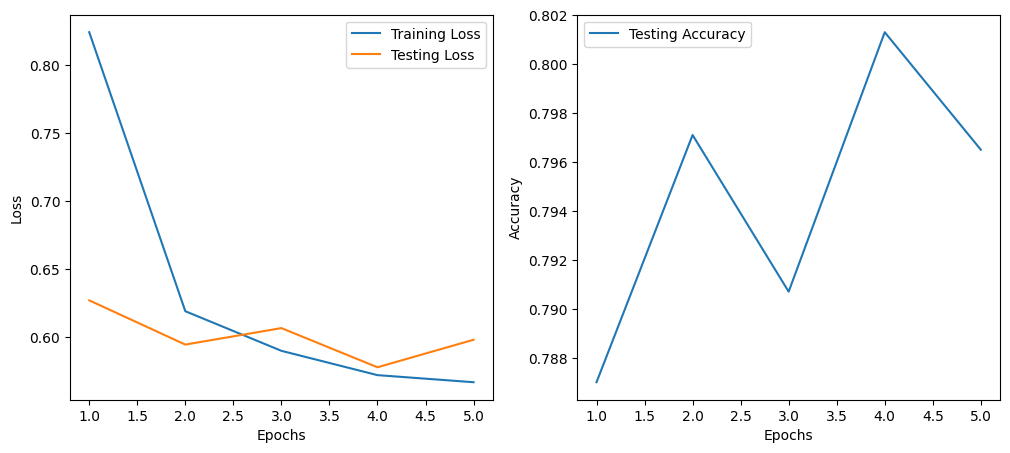

([0.8243826511875748,
  0.6191541380284692,
  0.5900186323715598,
  0.5721337827651397,
  0.5669188637791387],
 [0.6271328842563993,
  0.5945975649508701,
  0.6067356919027438,
  0.5779141703988336,
  0.5981507084931538],
 [0.787, 0.7971, 0.7907, 0.8013, 0.7965],
 0.8013)

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)



## 80% με πόσες παραμέτρους

Το ResNet18 μοντέλο είναι πάρα πολύ μεγάλο, και έχει εκατομμύρια παραμέτρους. Αλλά εμείς εκπαιδεύουμε μόνο το τελευταίο επίπεδο. Βλέπουμε πως έχει περίπου 5000 παραμέτρους που εκπαιδεύονται, και όμως πετύχαμε περίπου 80% ακρίβεια στα δεδομένα εκτίμησης. Αυτός ο αριθμός πρέπει να συγκριθεί με τον αριθμό παραμέτρων που είχαν τα μοντέλα μας στο [προγούμενο Notebook](https://colab.research.google.com/drive/1PMhVak3v8e5nCcvQEEGvBNdcLalYcCeW?usp=drive_link). Βλέπουμε πως η μας βοηθάν πολύ τα προεκπαιδευμένα επίπεδα, και ας εκπαιδεύτηκαν με άλλα δεδομένα.

In [ ]:
# Πόσες παραμέτρους έχει το μοντέλο μας
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
count_trainable_parameters(model)

5130

## Εκπαιδεύουμε όλο το νευρωνικό μας

"Ξεπαγώνουμε" όλες τις παραμέτρους σε όλα τα επίπεδα, και ξαναεκπαιδεύουμε με την ίδια εντολή. **Προσοχή**: πρέπει να ορίσουμε πάλι τον ``optimizer`` για να είμαστε σίγουροι πως εκπαιδεύει όλα τα επίπεδα. Θυμόμαστε πως ο ``optimizer`` διεξάγει μία τοπική αναζήτηση για καλύτερες παραμέτρους, δηλαδή ψάχνει κοντά στις τιμές που έχουν ήδη. Οπότε, πρέπει να του πούμε να ψάξει σε ολόκληρο τον χώρο των παραμέτρων και όχι μόνο των χώρο των τελευταίων παραμέτρων.


In [ ]:
# unfreeze all layers and train the whole network
for param in model.parameters():
    param.requires_grad = True

# redefine optimizer to include all parameters
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Epoch 1/5, Training Loss: 0.2770198719514072, Testing Loss: 0.19328842407009403, Testing Accuracy: 0.9348
Epoch 2/5, Training Loss: 0.08784380000646767, Testing Loss: 0.21156155245651484, Testing Accuracy: 0.9332
Epoch 3/5, Training Loss: 0.05111903193659242, Testing Loss: 0.21796445298204375, Testing Accuracy: 0.9358
Epoch 4/5, Training Loss: 0.04389273482621969, Testing Loss: 0.2149004541266306, Testing Accuracy: 0.9420
Epoch 5/5, Training Loss: 0.036979653947728224, Testing Loss: 0.22080821906969805, Testing Accuracy: 0.9405
Loaded the best model from epoch 4 with Testing Accuracy: 0.9420


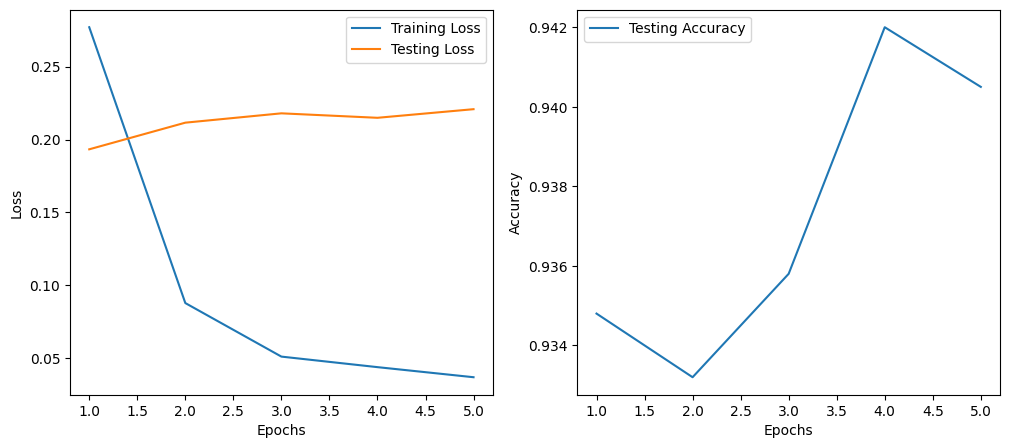

([0.2770198719514072,
  0.08784380000646767,
  0.05111903193659242,
  0.04389273482621969,
  0.036979653947728224],
 [0.19328842407009403,
  0.21156155245651484,
  0.21796445298204375,
  0.2149004541266306,
  0.22080821906969805],
 [0.9348, 0.9332, 0.9358, 0.942, 0.9405],
 0.942)

In [ ]:
# εκπαιδεύουμε
optimizer = optim.Adam(model.parameters(), lr=0.0001)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)

## Πως τα πήγαμε;

Η απόδοσή μας είναι σημαντικά καλύτερη, σε σχέση με την ακρίβεια που φτάσαμε στο προηγούμενο Notebook.

Είναι η πρώτη μας ένδειξη για τις δυνατότητες του Transfer Learning.

Εδώ τελειώνει και η εξερεύνηση μας των δεδομένων στην CIFAR-10.
* 24% ακρίβεια εκτίμησης με δέντρα απόφασης
* 34%, 65%, 86% ακρίβεια εκτίμησης με convolutional νευρωνικά δίκτυα
* 93% ακρίβεια εκτίμησης με Transfer Learning

In [ ]:
testaccuracy = evaluate(model, test_loader, device)
trainaccuracy = evaluate(model, train_loader, device)
print(f"Training Accuracy: {trainaccuracy * 100:.2f}%")
print(f"Testing Accuracy: {testaccuracy * 100:.2f}%")

Training Accuracy: 99.14%
Testing Accuracy: 94.20%


### Υπερμοντελοποίηση

Βλέπουμε πως και εδώ υπάρχει το στοιχείο της υπερμοντελοποίησης, μια που στα δεδομένα εκπαίδευσης πετυχαίνουμε σχεδόν 100% ακρίβεια.

### **Άσκηση**

Εκπαιδεύσαμε μόνο για 5 + 5 epochs. Έχουμε φτάσει τα όρια του δικτύου μας; Μπορείτε να το βελτιώσετε;

Δοκιμάστε να εκπαιδεύσετε με άλλες παραμέτρους του ``optimizer``, παραπάνω epochs, κ.ο.κ.